In [1]:
# Настройка окружения
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 

In [1]:
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import numpy as np
import random
import os
from torchvision.io import read_image
import kagglehub
from torchvision.ops.boxes import masks_to_boxes
from pathlib import Path
import torch
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torchvision.transforms import v2 as T
from torch.utils.data import DataLoader
import torchvision
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import copy

In [2]:
def fix_everything(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.backends.cudnn.benchmark = False

fix_everything(24)

# > Two-stage detection. Mask R-CNN



## Описание задачи



Закрепим знания, полученные на практическом занятии. В этом задании мы будем решать ту же задачу инстанс-сегментации людей, но на примере другого датасета. Вам придётся пройти те же этапы, что на практическом занятии, но реализовать их самостоятельно.



## План



1. Подготовка датасета

2. Подготовка модели

3. Обучение модели

4. Разбор метрики mAP


# > Подготовка датасета

Для начала скачаем датасет и посмотрим, из чего он состоит. Скачать его можно либо напрямую с kaggle, либо скачать архив.


In [4]:
dataset_path = kagglehub.dataset_download("tapakah68/segmentation-full-body-mads-dataset")
!cp -r $dataset_path .

Датасет состоит из трёх папок:
- `collages`: вспомогательные изображения, на которых изображены исходные файлы, маски и вырезанные по маске объекты;
- `images`: исходные файлы;
- `masks`: маски объектов.

Давайте посмотрим примеры из папки `collages`.

**Задание 1**. Реализуйте функцию `get_image_paths`, которая будет возвращать пути ко всем файлам заданного формата format ('.jpg', '.png' и т. д.), лежащим в папке `folder` в исходном датасете `dataset_path`. Папка `folder` может быть произвольной вложенности относительно `dataset_path`.

In [ ]:
dir(Path)

In [ ]:
/kaggle/input/datasets/tapakah68/segmentation-full-body-mads-dataset/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img/masks

In [ ]:
dataset_path

In [ ]:
form = "jpg"
folder = "collages"
x = Path(dataset_path).rglob(f"{folder}/*{form}")
image = read_image(next(x))
plt.imshow(image.permute(1, 2, 0))

In [3]:
# совпало с авторским
def get_image_paths(dataset_path, folder, format):
    """Находит все файлы формата format, лежащие в папке folder в исходном датасете dataset_path"""
    image_paths = Path(dataset_path).rglob(f"{folder}/*{format}")# Ваш код здесь
    return image_paths


Давайте посмотрим примеры из папки collages.

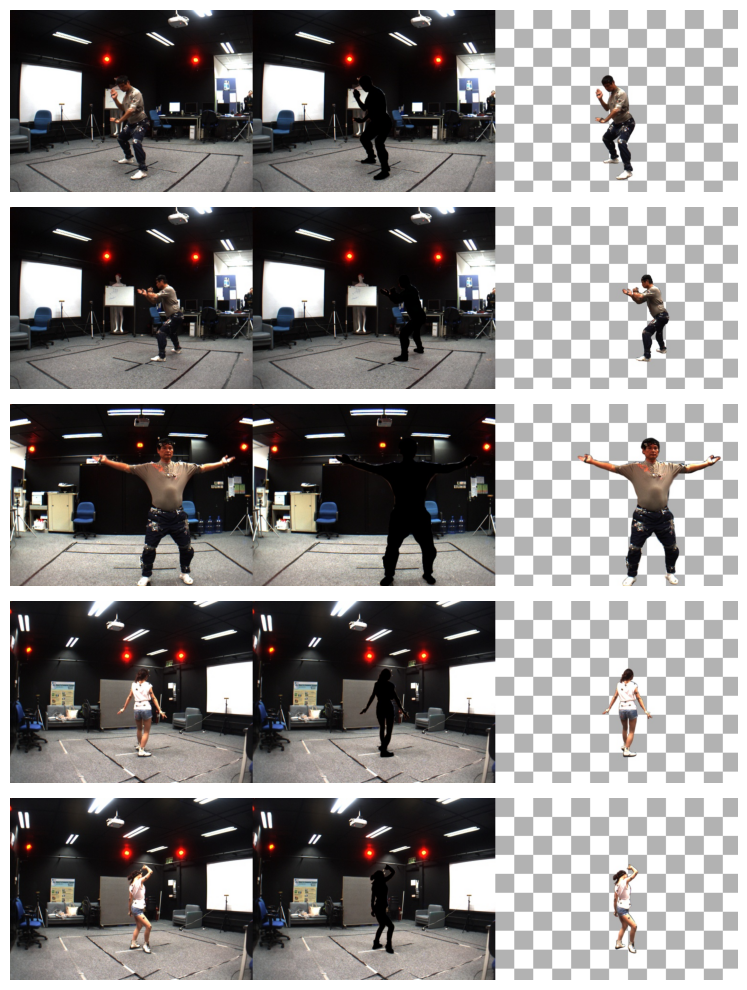

In [6]:
image_paths = get_image_paths(dataset_path, 'collages','jpg')
n = 5
fig, axes = plt.subplots(n, 1, figsize=(8, 2 * n))

for i, path in enumerate(image_paths):
  if i >= n:
    break
  image = read_image(path)
  axes[i].imshow(image.permute(1, 2, 0))
  axes[i].axis('off')
plt.tight_layout()
plt.show()


#### Подготовка масок

Рассмотрим теперь маски, c которыми будем работать.


mask.shape: torch.Size([4, 384, 512])


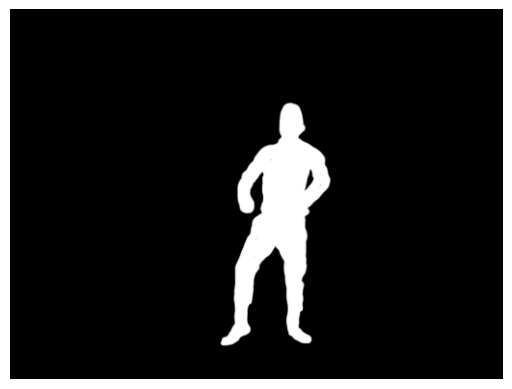

In [7]:
mask_paths = list(get_image_paths(dataset_path, 'masks', '.png'))
mask = read_image(mask_paths[0])
plt.imshow(mask.permute(1, 2, 0).numpy(), cmap='gray');
plt.axis('off');
print('mask.shape:', mask.shape)

In [8]:
x = (mask[0]).long()
x.unsqueeze(0).shape

torch.Size([1, 384, 512])

Хоть с виду маска и кажется чёрно-белой, на самом деле это 4-канальное RGB-изображение, где 4-й канал отвечает за прозрачность. Для обучения модели нам нужно привести маску к размерности (batch, height, width), в нашем случае это будет torch.Size([1, 384, 512]).

**Задание 2**. Напишите функцию fix_mask_shape, которая будет переводить 4-канальное изображение image в одноканальное изображение.




In [9]:
# совпало с авторским
def fix_mask_shape(image: torch.Tensor) -> torch.Tensor:
    """
    Переводит 4-канальное изображение image в одноканальное изображение:
    torch.Size([4, height, width]) -> torch.Size([1, height, width])
    """
    image = image[0].unsqueeze(0)
    return image

Теперь нужно бинаризовать маску, так как сейчас она в оттенках серого. Можем убедиться в этом, посмотрев, какие значения интенсивности принимают элементы маски.

In [ ]:
mask = fix_mask_shape(mask)
print(np.unique(mask))


**Задание 3**. Напишите функцию mask_binarization, которая заменит все значения маски, отличные от 0, на 1. Переведите полученный тензор в torch.uint8.

In [10]:
def mask_binarization(image:torch.Tensor) -> torch.Tensor:
    """
    Заменяет все значения маски, отличные от 0, на 1.
    Переводит полученный тензор в torch.uint8.
    """
    image = (image > 0).to(torch.uint8)
    return image

# от автора
def mask_binarization(image:torch.Tensor) -> torch.Tensor:
    """
    Заменяет все значения маски, отличные от 0, на 1.
    Переводит полученный тензор в torch.uint8.
    """
    image = (image > 0).type(torch.uint8)
    return image

In [11]:
mask = mask_binarization(mask)
print(np.unique(mask))


[0 1]



**Задание 4.** По аналогии с практическим занятием реализуйте метод __getitem__ для класса `Dataset`.
Считайте, что ранее реализованные функции `get_image_paths`, `fix_mask_shape` и `mask_binarization` уже импортированы.

In [12]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path, transforms=None):
        self.dataset_path = dataset_path
        self.transforms = transforms

        # get paths
        masks = list(get_image_paths(dataset_path, 'masks', '.png'))
        images = list(get_image_paths(dataset_path, 'images', '.png'))
        self.imgs = list(sorted(images))
        self.masks = list(sorted(masks))

    def __getitem__(self, idx):
        # get image
        img_path = self.imgs[idx]
        img = read_image(img_path)
        img = tv_tensors.Image(img)

        # get mask
        mask_path = self.masks[idx]
        mask = read_image(mask_path)
        mask = fix_mask_shape(mask)
        mask = mask_binarization(mask)

        # get boxes from mask
        boxes = masks_to_boxes(mask)

        # get_labels
        num_objs = 1
        labels = torch.ones((num_objs,), dtype=torch.int64)

        # get image_id
        image_id = idx

        # get_area
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        # get iscrowd (crowd у нас нет)
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # get target
        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target['masks'] = tv_tensors.Mask(mask)
        target['labels'] = labels
        target['image_id'] = image_id
        target['area'] = area
        target['iscrowd'] = iscrowd

        # transforms
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)

# от автора
class Dataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path, transforms=None):
        self.dataset_path = dataset_path
        self.transforms = transforms

        # Создаём списки фото и масок, сортируем, чтобы они совпадали по индексам
        masks = list(get_image_paths(dataset_path, 'masks', '.png'))
        images = list(get_image_paths(dataset_path, 'images', '.png'))
        self.imgs = list(sorted(images))
        self.masks = list(sorted(masks))
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def __getitem__(self, idx):
        # get image
        img_path = self.imgs[idx]
        img = read_image(img_path)
        img = tv_tensors.Image(img)

        # get mask
        mask_path = self.masks[idx]
        mask = read_image(mask_path)
        mask = fix_mask_shape(mask)
        mask = mask_binarization(mask)

        # get boxes
        boxes = masks_to_boxes(mask)

        # get_labels
        num_objs = 1
        labels = torch.ones((num_objs,), dtype=torch.int64)

        # get image_id
        image_id = idx

        # get_area
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        # get iscrowd (crowd у нас нет)
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # get target
        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_image_size(img)).to(self.device)
        target['masks'] = tv_tensors.Mask(mask).to(self.device)
        target['labels'] = labels.to(self.device)
        target['image_id'] = image_id
        target['area'] = area
        target['iscrowd'] = iscrowd

        # transforms
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img.to(self.device), target

    def __len__(self):
        return len(self.imgs)

Датасет мы подготовили, теперь нужно подготовить dataloader. Для этого нам понадобятся вспомогательные функции get_transform и collate_fn.





In [ ]:
def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

def collate_fn(batch):
    return list(zip(*batch))

dataset_train = Dataset(dataset_path, get_transform(train=True))
dataset_test = Dataset(dataset_path, get_transform(train=False))

In [ ]:
len(dataset_train)

**Задание 5.** Реализуйте функцию get_dataloaders. На вход функция должна принимать подготовленные датасеты, количество файлов, которые будут выделены в тестовый датасет, размер батча и функцию для объединения данных в батч.
На выход функция должна выдавать два даталоудера (train и test).

In [13]:
# совпало с автором
def get_dataloaders(dataset_train, dataset_test, num_test_files, batch_size, collate_fn):
    indices = torch.randperm(len(dataset_train)).tolist()
    train_dataset = torch.utils.data.Subset(dataset_train, indices[:-num_test_files])
    test_dataset = torch.utils.data.Subset(dataset_test, indices[-num_test_files:])
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size,
        shuffle=True, 
        collate_fn=collate_fn,
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        collate_fn=collate_fn,
    )
    return train_loader, test_loader

In [ ]:
from torchvision.utils import make_grid

train_loader, test_loader = get_dataloaders(dataset_train, dataset_test, 120, 32, collate_fn=collate_fn)
images, targets = next(iter(train_loader))
masks = torch.stack([t["masks"] for t in targets])
print(masks.shape)
print(masks.dtype)
print(masks.min(), masks.max())
print(torch.unique(masks))

# grid_mask = make_grid(masks[:8], nrow=4, padding=2).cpu()
# grid_mask_np = grid_mask.permute(1, 2, 0).numpy()

grid_mask = make_grid(masks[:8] * 255, nrow=4, padding=2).cpu()
grid_mask_np = grid_mask.permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 6))
plt.imshow(grid_mask_np.squeeze(), cmap="gray")
plt.show()

In [ ]:
train_loader, test_loader = get_dataloaders(dataset_train, dataset_test, 120, 32, collate_fn=collate_fn)
images, targets = next(iter(train_loader))
images = torch.stack([t for t in images])
masks = torch.stack([t["masks"] for t in targets])

pairs = []

for i in range(8):
    pairs.append(images[i])
    pairs.append(masks[i].expand(3, -1, -1).float())

pairs = torch.stack(pairs)

grid = make_grid(
    pairs,
    nrow=4,
    padding=2,
).cpu()

grid_np = grid.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 10))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

Даталоудер готов, можем приступить к загрузке модели. Для этой задачи будем использовать модель `maskrcnn_resnet50_fpn_v2`.






In [ ]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(weights='DEFAULT')
torch.save(model.state_dict(), 'maskrcnn_resnet50_fpn_v2.pth')

**Задание 6**. Реализуйте функцию `prepare_model` для настройки модели. Адаптируйте архитектуру модели, чтобы она предсказывала два класса.




In [ ]:
model

In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor # голова для предсказания боксов
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor # голова для предсказания масок

# совпало с автором
def prepare_model(model, num_classes):
  in_features = model.roi_heads.box_predictor.cls_score.in_features
  model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
  
  in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
  hidden_layer = 256
  model.roi_heads.mask_predictor = MaskRCNNPredictor(
      in_features_mask, hidden_layer, num_classes)
  return model

model = prepare_model(model, num_classes=2)

## > Обучение модели
В этот раз для обучения модели воспользуемся библиотекой
PyTorch Lightning. Lightning берёт на себя рутинные задачи по управлению процессами обучения, и остаётся реализовать только основную логику, специфичную для конкретной модели.

Перед тем как начать обучение, определим две вспомогательные функции, чтобы более компактно выводить метрики и лоссы.



> *По-хорошему, метрики, лоссы и любую другую информацию об эксперименте лучше легировать с помощью специальных инструментов, таких как tensorboard, ml flow, wandb, clearm и т. д., но сейчас для простоты выведем их на печать.*





In [ ]:
def print_losses(loss_dict, batch_idx):
    formatted_losses = {}
    for key, value in loss_dict.items():
        formatted_value = value.item()
        formatted_losses[key] = round(formatted_value, 4) if -1e-2 < formatted_value < 1e2 else f"{formatted_value:.2e}"
    if batch_idx % 100 == 0:
      print()
      for name, val in formatted_losses.items():
          print(f"{name}: {val}", end=' | ')
    return formatted_losses

def print_metrics(metrics):
    for key, value in metrics.items():
      if isinstance(value, torch.Tensor):
        value = value.cpu().numpy()
        print(f'{key}: {value:.4f}', end=' |')
    print()


 Практически всё необходимое для обучения Lightning делает под капотом, нам остаётся настроить параметры обучения и следить за метриками.

  **Задание 7**. Дополните метод configure_optimizers и обучите модель.

In [ ]:
import pytorch_lightning as pl
import torch
import torchmetrics

def parse_predictions(predictions):
  preds = []
  for i in range(len(predictions)):
      preds.append({
          "boxes": predictions[i]['boxes'],
          "scores": predictions[i]['scores'],
          "labels": predictions[i]['labels']
      })
  return preds

def parse_targets(targets):
  gts = []
  for i in range(len(targets)):
    gts.append({
        "boxes": targets[i]['boxes'],
        "labels": targets[i]['labels']
    })
  return gts

class LightningMaskRCNN(pl.LightningModule):
    def __init__(self, model):
        super().__init__()
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = model
        self.model.train()
        self.model.to(device)
        self.val_metrics = torchmetrics.MetricCollection({
            "AP": torchmetrics.detection.mean_ap.MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)
        })
        self.batch_metric_results = []

    def forward(self, images, targets=None):
        return self.model(images, targets)

    def training_step(self, batch, batch_idx):
        images, targets = batch
        loss_dict = self.model(images, targets)
        print_losses(loss_dict, batch_idx)
        loss = sum(loss for loss in loss_dict.values())
        return loss

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        with torch.no_grad():
            predictions = self.model(images)

        # Преобразуем в подходящий формат
        preds = parse_predictions(predictions)
        gt = parse_targets(targets)

        # Обновляем метрики для всего батча
        self.val_metrics.update(preds=preds, target=gt)

    def on_validation_epoch_end(self):
        # Вычисляем метрики
        metrics = self.val_metrics.compute()
        # Печатаем метрики
        print_metrics(metrics)
        # Сбрасываем метрики для следующей эпохи
        self.val_metrics.reset()

    def configure_optimizers(self):
        params = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
        scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
        return [optimizer], [scheduler]


In [ ]:
%%time
model = prepare_model(model, num_classes=2)
lightning_model = LightningMaskRCNN(model)

train_loader, test_loader = get_dataloaders(
    dataset_train, 
    dataset_test, 
    120, 2, 
    collate_fn=collate_fn)

max_epochs = 3
accelerator = "gpu"
trainer = pl.Trainer(
    max_epochs=max_epochs, 
    accelerator=accelerator,
    logger=False,
    enable_progress_bar=False)

trainer.fit(lightning_model, train_loader, test_loader)

Веса обученной модели сохраните в файл model_weights.pth и загрузите их для проверки.

Модель будет протестирована на небольшой отложенной выборке и будет проверять, что среднее значение mAP > 0.5.



In [ ]:
torch.save(model.state_dict(), 'model_weights.pth')

In [ ]:
model.load_state_dict(torch.load('model_weights.pth'))

Посмотрим глазами на результат и убедимся, что модель чему-то научилась.

In [ ]:
# Загрузка и предобработка изображения
image = read_image(list(get_image_paths(dataset_path, 'images', '.png'))[0])
x = get_transform(train=False)(image)[:3].to('cuda')

# Инференс модели без градиентов
model.eval().to('cuda')
with torch.no_grad():
    pred = model([x])[0]

# Обработка предсказаний
max_score_idx = int(pred['scores'].argmax())
masks = (pred['masks'] > 0.1).squeeze(1)[max_score_idx]
pred_boxes = pred['boxes'][max_score_idx].long().unsqueeze(0)

# Отрисовка рамок и масок
image = draw_bounding_boxes(image, pred_boxes, ['label'], colors="red")
image = draw_segmentation_masks(image, masks, alpha=0.5, colors="blue")

# Визуализация результата
plt.figure(figsize=(10, 8))
plt.axis('off')
plt.imshow(image.permute(1, 2, 0))
plt.show()

In [ ]:
print(len(dataset_train))
print(len(dataset_test))

print(len(train_loader))
print(len(test_loader))

In [ ]:
metrics = torchmetrics.MetricCollection({
            "AP": torchmetrics.detection.mean_ap.MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)
        })
model = model.to('cuda')
all_preds = []
all_gt = []
for batch in test_loader:
  images, targets = batch
  # print(images)
  with torch.no_grad():
      predictions = model(images)
  preds = parse_predictions(predictions)
  gt = parse_targets(targets)
  metrics.update(preds=preds, target=gt)
  all_preds.append(preds)
  all_gt.append(gt)
metrics = metrics.compute()
print_metrics(metrics)

In [ ]:
assert metrics['map'].item() > 0.5

# > Разбор метрики mAP
Давайте разберём, как рассчитывается метрика `mAP` (mean Average Precision). Чтобы лучше понять эту метрику, реализуем её самостоятельно на простом примере детекции объектов с двумя классами:

   - красные прямоугольники,

   - зелёные прямоугольники.

У нас есть датасет, состоящий из 10 изображений. Для каждого изображения имеются предсказания от детектора, и мы хотим оценить качество этих предсказаний. На каждой картинке закрашенные прямоугольники представляют истинные объекты, а пунктирные линии — предсказания детектора.

Датасет искусственный, поэтому руками зададим данные о расположении объектов и предсказаниях детектора.

In [4]:
data = [
    {
        "gt": [(10, 10, 50, 50), 1],
        "predictions": [
            ((12, 12, 48, 48), 1, 0.9),

            ((5, 5, 25, 25), 2, 0.5),
            ((60, 60, 80, 80), 1, 0.4)
        ]
    },
    {
        "gt": [(60, 60, 100, 100), 1],
        "predictions": [
            ((62, 62, 98, 98), 1, 0.95),
            ((20, 20, 50, 50), 1, 0.2),
            ((80, 80, 120, 120), 2, 0.6)
        ]
    },
    {
        "gt": [(30, 30, 70, 70), 2],
        "predictions": [
            ((32, 30, 68, 70), 2, 0.85),
            ((35, 40, 60, 75), 1, 0.4),
            ((95, 105, 75, 75), 2, 0.3)
        ]
    },
    {
        "gt": [(50, 50, 90, 90), 2],
        "predictions": [
            ((52, 52, 88, 88), 2, 0.7),
            ((45, 45, 85, 85), 1, 0.89),
            ((80, 80, 100, 100), 2, 0.65)
        ]
    },
    {
        "gt": [(70, 70, 110, 110), 1],
        "predictions": [
            ((72, 72, 108, 108), 1, 0.4),
            ((75, 75, 115, 115), 2, 0.1),
            ((90, 90, 130, 130), 1, 0.5)
        ]
    },
    {
        "gt": [(15, 15, 55, 55), 2],
        "predictions": [
            ((17, 17, 53, 53), 2, 0.8),
            ((20, 20, 60, 60), 1, 0.25),
            ((5, 5, 45, 45), 2, 0.2)
        ]
    },
    {
        "gt": [(40, 40, 80, 80), 1],
        "predictions": [
            ((42, 42, 78, 78), 1, 0.91),
            ((100, 100, 85, 85), 1, 0.3),
            ((60, 60, 100, 100), 2, 0.4)
        ]
    },
    {
        "gt": [(25, 25, 65, 65), 2],
        "predictions": [
            ((28, 28, 62, 62), 2, 0.9),
            ((30, 30, 70, 70), 1, 0.35),
            ((50, 50, 90, 90), 2, 0.5)
        ]
    },
    {
        "gt": [(55, 55, 95, 95), 2],
        "predictions": [
            ((57, 57, 93, 93), 2, 0.6),
            ((50, 50, 90, 90), 1, 0.3),
            ((70, 70, 110, 110), 2, 0.75)
        ]
    },
    {
        "gt": [(45, 45, 85, 85), 1],
        "predictions": [
            ((48, 48, 82, 82), 1, 0.69),
            ((40, 40, 80, 80), 2, 0.31),
            ((60, 60, 100, 100), 1, 0.45)
        ]
    }
]


Посмотрим на наш датасет.

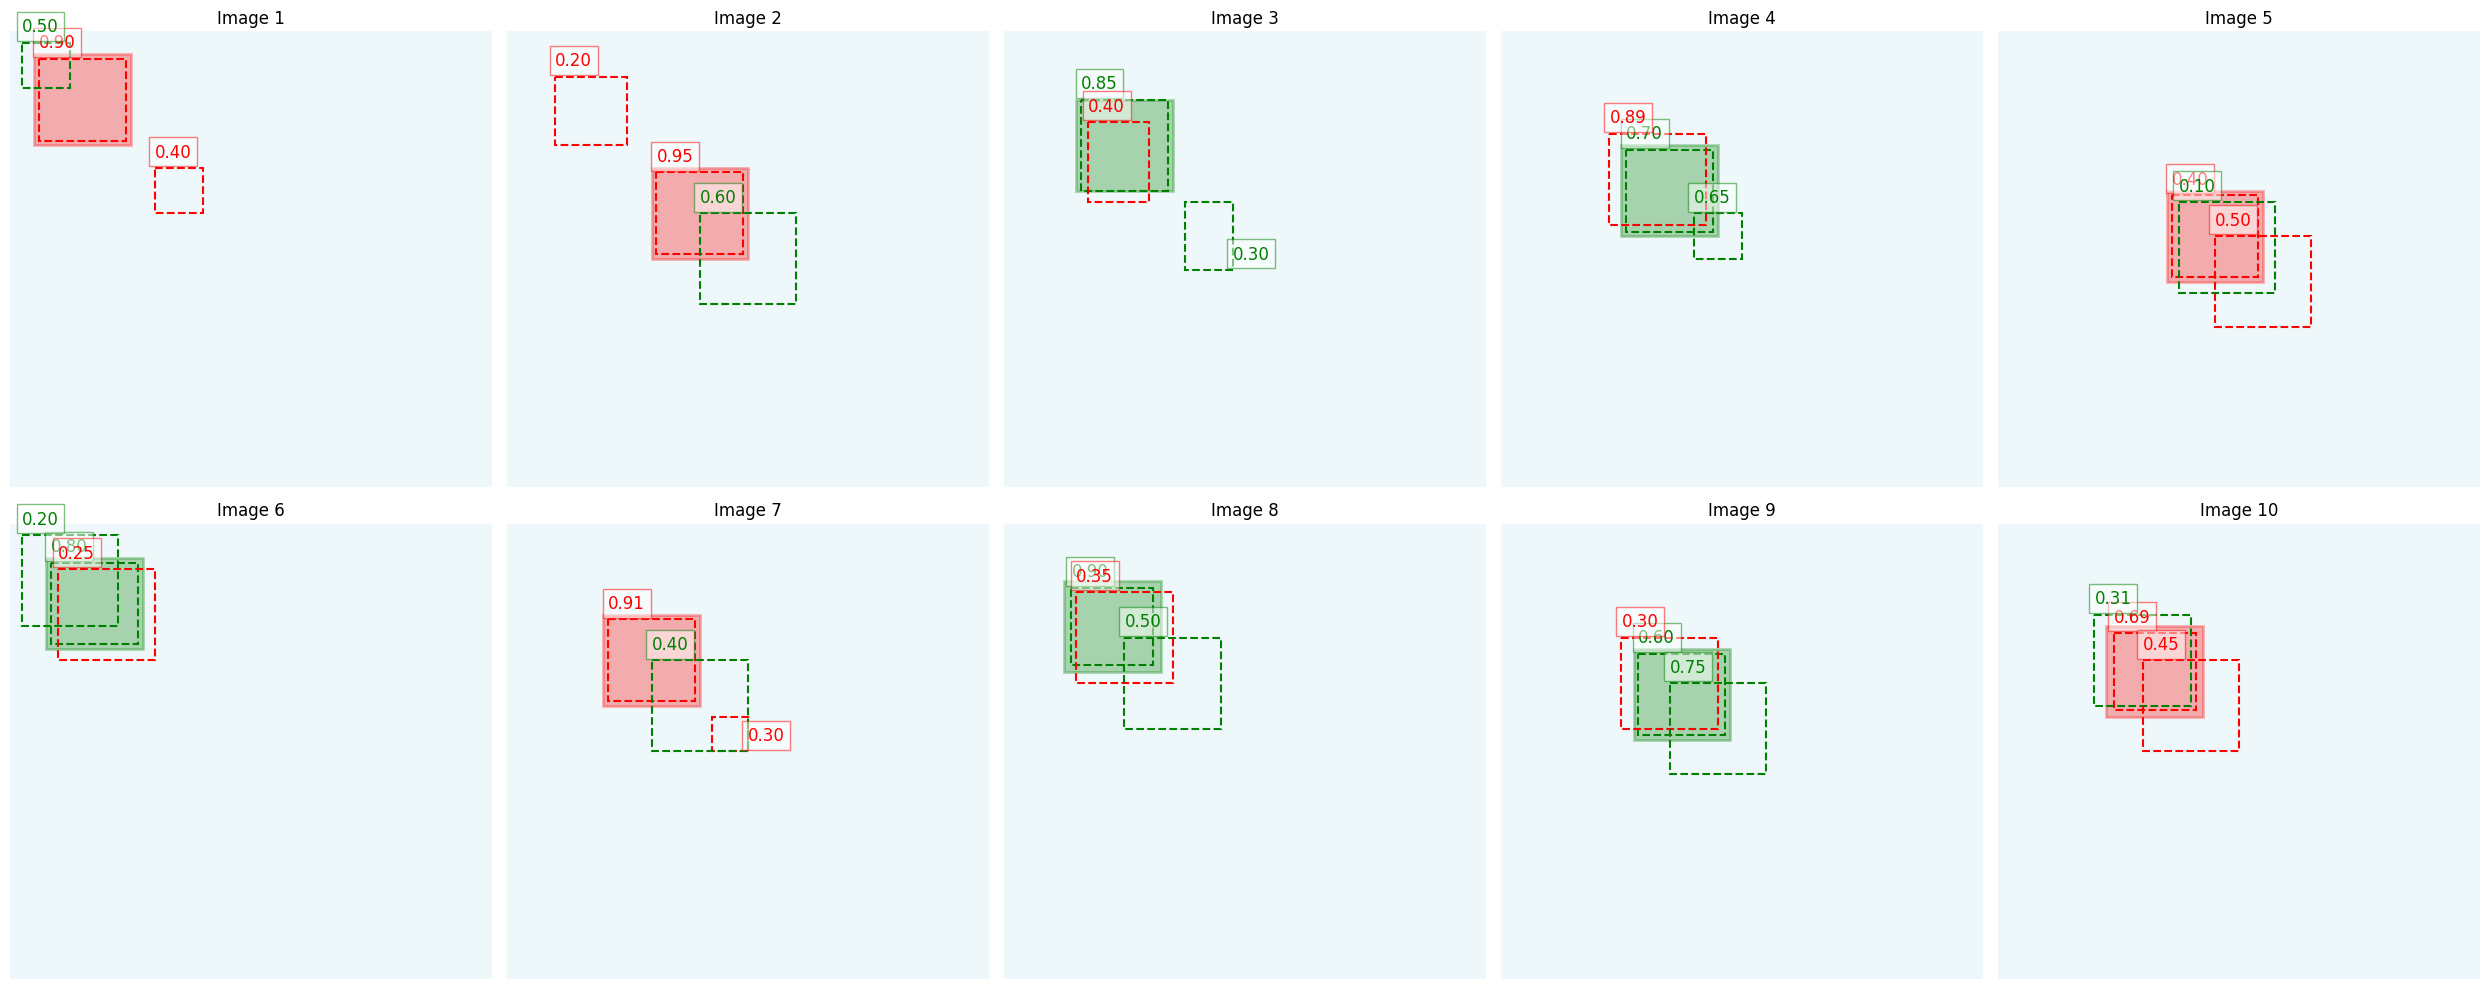

In [5]:
def visualize_data(data):
    # Задаём цвета для трёх классов
    colors = ['red', 'green', 'blue']

    # Создаём фигуру и субплоты
    num_images = len(data)
    nrows = 2
    ncols = (num_images + 1) // 2

    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axs = axs.ravel()

    for idx, image_data in enumerate(data):
        ax = axs[idx]
        ax.set_title(f"Image {idx + 1}")

        # Добавляем светло-голубой полупрозрачный фон
        rect_bg = patches.Rectangle((0, 0), 200, 200, linewidth=0, edgecolor='none', facecolor='lightblue', alpha=0.2)
        ax.add_patch(rect_bg)

        # Обработка ground truth
        gt_bbox, gt_class = image_data['gt']
        gt_color = colors[gt_class - 1]
        rect = patches.Rectangle((gt_bbox[0], gt_bbox[1]), gt_bbox[2] - gt_bbox[0], gt_bbox[3] - gt_bbox[1],
                                 linewidth=2, edgecolor=gt_color, facecolor=gt_color, alpha=0.3)
        ax.add_patch(rect)

        # Обработка предсказаний
        for pred_bbox, pred_class, confidence in image_data['predictions']:
            pred_color = colors[pred_class - 1]
            rect = patches.Rectangle((pred_bbox[0], pred_bbox[1]), pred_bbox[2] - pred_bbox[0], pred_bbox[3] - pred_bbox[1],
                                     linewidth=1.5, edgecolor=pred_color, facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(pred_bbox[0], pred_bbox[1] - 5, f"{confidence:.2f}", color=pred_color, fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor=pred_color))

        # Отключаем оси для красоты
        ax.set_xlim(0, 200)
        ax.set_ylim(0, 200)
        ax.invert_yaxis()
        ax.axis('off')

    # Удаляем неиспользуемые субплоты, если есть
    for j in range(idx + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

visualize_data(data)


Теперь, когда мы разобрались с данными, давайте сосредоточимся на реализации подсчёта mAP. Мы можем выделить несколько основных этапов:

1. Определение TP и FP для каждого предсказания:

   - Для каждого предсказания необходимо определить, является ли оно истинным положительным (TP) или ложным положительным (FP), используя заданный порог IoU.

2. Построение кривой Precision-Recall:

   - На основе отсортированных предсказаний создайте кривую Precision-Recall, вычисляя точность (precision) и полноту (recall) для различных порогов уверенности.

3. Расчёт Average Precision (AP):

   - Рассчитайте AP, используя полученные значения точности и полноты.

4. Агрегация результатов:

   - Объедините результаты по всем классам и заданным порогам IoU для получения финальной метрики mAP.

Таким образом вы сможете оценить качество работы своего детектора, учитывая разные классы и пороги IoU.

# Определение TP и FP для каждого предсказания

Функцию `calculate_iou(bbox, gt_bbox)` мы уже реализовывали на предыдущих занятиях, сейчас не будем на неё отвлекаться и возьмём готовую реализацию.

In [7]:
def calculate_iou(box1, box2):
    """
    Рассчитывает IoU между двумя bbox.

    :param box1: Координаты первого bbox в формате (xmin, ymin, xmax, ymax).
    :param box2: Координаты второго bbox в формате (xmin, ymin, xmax, ymax).
    :return: Значение IoU от 0 до 1.
    """
    # Определение координат пересечения
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Если пересечения нет, IoU равно 0
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # Вычисление площади пересечения
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Вычисление площади каждого прямоугольника
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Вычисление площади объединения
    union_area = box1_area + box2_area - intersection_area

    # Вычисление IoU
    iou = intersection_area / union_area

    return iou



**Задание 8.**  Необходимо реализовать функцию `classify_tp_fp_predictions` для оценки предсказанных боксов.

Для каждого изображения из датасета нужно пройтись по всем предсказанным боксам и определить их либо к истинным положительным (TP), либо к ложным положительным (FP) в соответствии с заданным порогом IoU.

В результате функция должна сформировать датафрейм cо слeдующими столбцами:

   - label — предсказанный класс.

   - confidence — уровень уверенности предсказания.

   - tp — 1, если предсказание является истинным положительным, иначе 0.

   - fp — 1, если предсказание является ложным положительным, иначе 0.

Датафрейм должен быть отсортирован по убыванию значения confidence.

In [14]:
def classify_tp_fp_predictions(data, iou_threshold=0.5):
    lines = []
    gt_labels = []
    gt, predictions = data[0].values()

    for i, current_data in enumerate(data):
        gt, predictions = current_data.values()
        gt_bbox, gt_label = gt
        gt_labels.append(gt_label)

        for (bbox, label, confidence) in predictions:
            # Запишите результаты в таком формате: line = {'label': ..., 'confidence': ..., 'tp': ..., 'fp': ...}
            iou = calculate_iou(bbox, gt_bbox)
            # Ваш код здесь
            if label == gt_label and iou > iou_threshold:
                tp = 1
            else:
                tp = 0
            line = {'label': label, 
                    'confidence': confidence,
                    'tp': tp,
                    'fp': 1-tp}
            lines.append(line)
    df = pd.DataFrame(lines)
    sorted_df = df.sort_values(by='confidence', ascending=False)
    return sorted_df

# от автора
def classify_tp_fp_predictions(data, iou_threshold=0.5):
    lines = []
    gt_labels = []
    gt, predictions = data[0].values()

    for i, current_data in enumerate(data):
        gt, predictions = current_data.values()
        gt_bbox, gt_label = gt
        gt_labels.append(gt_label)

        for (bbox, label, confidence) in predictions:
            iou = calculate_iou(bbox, gt_bbox)
            if iou > iou_threshold and label == gt_label:
                line = {'label': gt_label, 'confidence': confidence, 'tp': 1, 'fp': 0}
            else:
                line = {'label': label, 'confidence': confidence, 'tp': 0, 'fp': 1}
            lines.append(line)
    df = pd.DataFrame(lines)
    sorted_df = df.sort_values(by='confidence', ascending=False)
    return sorted_df


Давайте посмотрим на получившийся результат.

In [15]:
df = classify_tp_fp_predictions(data, iou_threshold=0.5)
print(df.to_string(index=False))

 label  confidence  tp  fp
     1        0.95   1   0
     1        0.91   1   0
     2        0.90   1   0
     1        0.90   1   0
     1        0.89   0   1
     2        0.85   1   0
     2        0.80   1   0
     2        0.75   0   1
     2        0.70   1   0
     1        0.69   1   0
     2        0.65   0   1
     2        0.60   0   1
     2        0.60   1   0
     2        0.50   0   1
     2        0.50   0   1
     1        0.50   0   1
     1        0.45   0   1
     2        0.40   0   1
     1        0.40   0   1
     1        0.40   1   0
     1        0.40   0   1
     1        0.35   0   1
     2        0.31   0   1
     1        0.30   0   1
     2        0.30   0   1
     1        0.30   0   1
     1        0.25   0   1
     1        0.20   0   1
     2        0.20   0   1
     2        0.10   0   1



# Построение Precision-Recall — кривой

Precision-Recall — кривая строится для каждого класса отдельно, поэтому нам нужно разделить нашу таблицу на две, в каждой из которых будут предсказания только одного класса.

In [27]:
grouped = df.groupby('label')
label_to_df = {}
for label, group in grouped:
    label_to_df[label] = group

df_label_1 = label_to_df[1]
df_label_2 = label_to_df[2]

In [28]:
grouped

In [17]:
print('Label 1:')
print(df_label_1.to_string(index=False))


Label 1:
 label  confidence  tp  fp
     1        0.95   1   0
     1        0.91   1   0
     1        0.90   1   0
     1        0.89   0   1
     1        0.69   1   0
     1        0.50   0   1
     1        0.45   0   1
     1        0.40   0   1
     1        0.40   1   0
     1        0.40   0   1
     1        0.35   0   1
     1        0.30   0   1
     1        0.30   0   1
     1        0.25   0   1
     1        0.20   0   1


Для построения `precision recall` — кривой нам нужно рассчитать кумулятивную сумму по столбцам tp и fp. Кумулятивная сумма позволяет увидеть, как производительность модели изменяется в зависимости от уровня уверенности предсказаний.

**Задание 9.** Напишите функцию `counut_cum_sum()` для расчёта кумулятивной суммы в столбцах tp и fp. Результаты добавьте в столбцы cs_TP и cs_FP соответственно.


In [18]:
def counut_cum_sum(df):
  df['cs_TP'] = df['tp'].cumsum()
  df['cs_FP'] = df['fp'].cumsum()
  return df

In [19]:
df_label_1 = counut_cum_sum(df_label_1)
df_label_2 = counut_cum_sum(df_label_2)
print('Label 1:')
print(df_label_1.to_string(index=False))

Label 1:
 label  confidence  tp  fp  cs_TP  cs_FP
     1        0.95   1   0      1      0
     1        0.91   1   0      2      0
     1        0.90   1   0      3      0
     1        0.89   0   1      3      1
     1        0.69   1   0      4      1
     1        0.50   0   1      4      2
     1        0.45   0   1      4      3
     1        0.40   0   1      4      4
     1        0.40   1   0      5      4
     1        0.40   0   1      5      5
     1        0.35   0   1      5      6
     1        0.30   0   1      5      7
     1        0.30   0   1      5      8
     1        0.25   0   1      5      9
     1        0.20   0   1      5     10


В результате мы получили таблицы, из которых видно, как с уменьшением уверенности модели меняется количество TP и FP.

На основе этих данных мы можем рассчитать метрики Precision и Recall.

Precision = TP / (TP + FP)

Recall = TP / Num objects

In [20]:
def count_precision_recall(df, num_objects):
  df['precision'] = df['cs_TP']/(df['cs_TP']+df['cs_FP'])
  df['recall'] = df['cs_TP']/ num_objects
  return df

In [21]:
df_label_1 = count_precision_recall(df_label_1, num_objects=5)
df_label_2 = count_precision_recall(df_label_2, num_objects=5)
print('Label 1:')
print(df_label_1.to_string(index=False))


Label 1:
 label  confidence  tp  fp  cs_TP  cs_FP  precision  recall
     1        0.95   1   0      1      0   1.000000     0.2
     1        0.91   1   0      2      0   1.000000     0.4
     1        0.90   1   0      3      0   1.000000     0.6
     1        0.89   0   1      3      1   0.750000     0.6
     1        0.69   1   0      4      1   0.800000     0.8
     1        0.50   0   1      4      2   0.666667     0.8
     1        0.45   0   1      4      3   0.571429     0.8
     1        0.40   0   1      4      4   0.500000     0.8
     1        0.40   1   0      5      4   0.555556     1.0
     1        0.40   0   1      5      5   0.500000     1.0
     1        0.35   0   1      5      6   0.454545     1.0
     1        0.30   0   1      5      7   0.416667     1.0
     1        0.30   0   1      5      8   0.384615     1.0
     1        0.25   0   1      5      9   0.357143     1.0
     1        0.20   0   1      5     10   0.333333     1.0


Теперь мы можем построить Precision-Recall — кривую для каждого класса и наглядно увидеть, как меняются метрики с уменьшением уверенности модели.


In [23]:
def plot_PR_curve(df,):
    plt.figure(figsize=(8, 6))
    plt.plot(df['recall'], df['precision'], marker='o', linestyle='-', color='b', label='Precision-Recall')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()

label 1


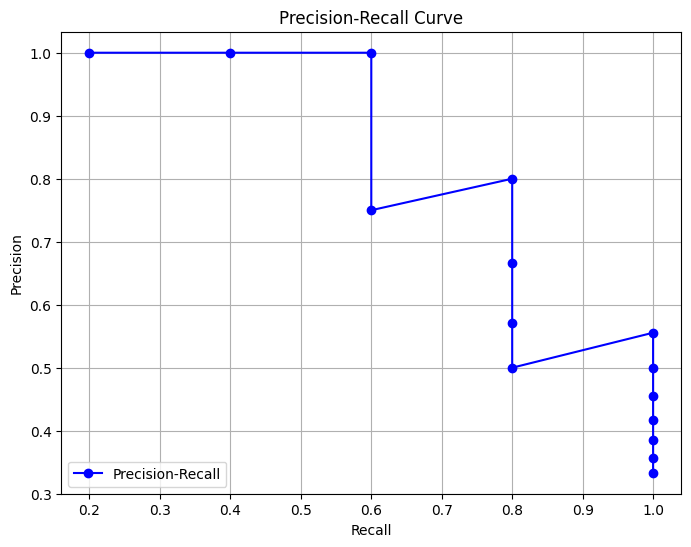

In [24]:
print('label 1')
plot_PR_curve(df_label_1)

# Average Precision
Для подсчёта Average Precision нам нужно рассчитать площадь под Precision-Recall — кривой. Есть разные способы это сделать. Мы разделим график на прямоугольные участки и посчитаем сумму площадей таких прямоугольников.

In [25]:
def average_precision(df):
  AP = 0
  prev_recall = 0
  for i in range(len(df)):
      recall = df['recall'].iloc[i]
      precision = df['precision'].iloc[i]
      last_ap = copy.copy(AP)
      AP += (recall - prev_recall) * precision
      print(f'{last_ap} + ({recall} - {prev_recall}) * {round(precision,2)}, AP={AP}')
      prev_recall = recall
  return AP

AP = average_precision(df_label_1)

0 + (0.2 - 0) * 1.0, AP=0.2
0.2 + (0.4 - 0.2) * 1.0, AP=0.4
0.4 + (0.6 - 0.4) * 1.0, AP=0.6
0.6 + (0.6 - 0.6) * 0.75, AP=0.6
0.6 + (0.8 - 0.6) * 0.8, AP=0.76
0.76 + (0.8 - 0.8) * 0.67, AP=0.76
0.76 + (0.8 - 0.8) * 0.57, AP=0.76
0.76 + (0.8 - 0.8) * 0.5, AP=0.76
0.76 + (1.0 - 0.8) * 0.56, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.5, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.45, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.42, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.38, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.36, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.33, AP=0.8711111111111111


Посмотрим, как это выглядит на графике.

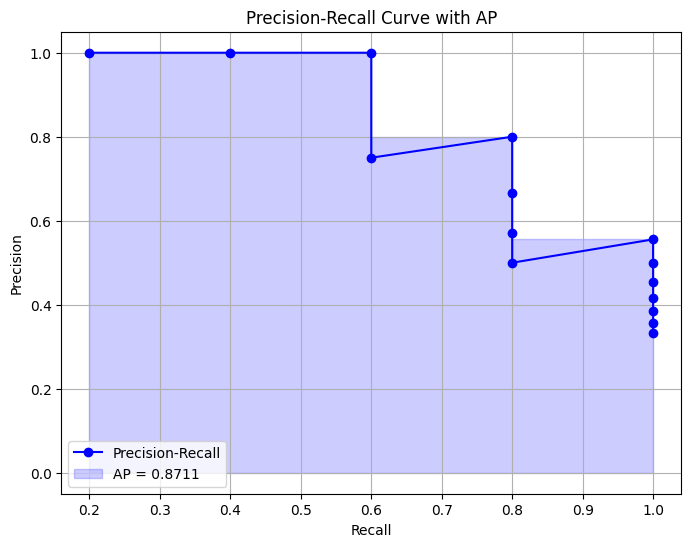

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(df_label_1['recall'], df_label_1['precision'], marker='o', linestyle='-', color='b', label='Precision-Recall')
plt.fill_between(df_label_1['recall'], df_label_1['precision'], step='pre', alpha=0.2, color='b', label=f'AP = {AP:.4f}')
plt.title('Precision-Recall Curve with AP')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Mean Average Precision

Теперь настало время всё усреднять. В предыдущих примерах мы оценивали TP и FP для порога IoU = 0.5 и посчитали AP для класса 1.

Для расчёта mAP для одного класса нам понадобится посчитать AP для каждого порога IoU от 0.5 до 0.95 с шагом 0.05 и усреднить их.

Чтобы посчитать mAP по всем классам, нужно всего лишь усреднить значения mAP по каждому классу.

**Задание 11**. Реализуйте пайплайн для подсчёта mAP.

In [33]:
num_obj = defaultdict(int)
for obj in data:
    num_obj[obj["gt"][1]] += 1
num_obj
num_obj_1 = num_obj[1]
num_obj_2 = num_obj[2]
num_obj_1, num_obj_2 

(5, 5)

In [36]:
from collections import defaultdict

def mAP_pipeline(data):
    """Вычисляет mean Average Precision для порогов с 0.5 до 0.95 с шагом 0.05."""
    thresholds = [0.5 + t*0.05 for t in range(10)]
    num_obj = defaultdict(int)
    AP = defaultdict(int)
    for obj in data:
        num_obj[obj["gt"][1]] += 1
    num_obj_1 = num_obj[1]
    num_obj_2 = num_obj[2]
    
    for thres in thresholds:
        df = classify_tp_fp_predictions(data, iou_threshold=thres)
        grouped = df.groupby('label')
        label_to_df = {}
        for label, group in grouped:
            label_to_df[label] = group
        
        df_label_1 = label_to_df[1]
        df_label_2 = label_to_df[2]
        df_label_1 = counut_cum_sum(df_label_1)
        df_label_2 = counut_cum_sum(df_label_2)
        df_label_1 = count_precision_recall(df_label_1, num_objects=num_obj_1)
        df_label_2 = count_precision_recall(df_label_2, num_objects=num_obj_2)
        AP[1] += average_precision(df_label_1)
        AP[2] += average_precision(df_label_2)
    
    mAP = sum(AP.values())/len(AP)/len(thresholds)
    return mAP

mAP_pipeline(data)

0 + (0.2 - 0) * 1.0, AP=0.2
0.2 + (0.4 - 0.2) * 1.0, AP=0.4
0.4 + (0.6 - 0.4) * 1.0, AP=0.6
0.6 + (0.6 - 0.6) * 0.75, AP=0.6
0.6 + (0.8 - 0.6) * 0.8, AP=0.76
0.76 + (0.8 - 0.8) * 0.67, AP=0.76
0.76 + (0.8 - 0.8) * 0.57, AP=0.76
0.76 + (0.8 - 0.8) * 0.5, AP=0.76
0.76 + (1.0 - 0.8) * 0.56, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.5, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.45, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.42, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.38, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.36, AP=0.8711111111111111
0.8711111111111111 + (1.0 - 1.0) * 0.33, AP=0.8711111111111111
0 + (0.2 - 0) * 1.0, AP=0.2
0.2 + (0.4 - 0.2) * 1.0, AP=0.4
0.4 + (0.6 - 0.4) * 1.0, AP=0.6
0.6 + (0.6 - 0.6) * 0.75, AP=0.6
0.6 + (0.8 - 0.6) * 0.8, AP=0.76
0.76 + (0.8 - 0.8) * 0.67, AP=0.76
0.76 + (0.8 - 0.8) * 0.57, AP=0.76
0.76 + (1.0 - 0.8) * 0.62, AP=0.885
0.885 + (1.0 - 1.0) * 0.56, AP=0.885
0.885 + (1.

np.float64(0.5582499999999999)

In [37]:
# решение автора
from collections import defaultdict
def mAP_pipeline(data):
  label_to_ap = defaultdict(list)
  
  for iou_th in np.arange(0.5, 1, 0.05):
    tp_fp_df = classify_tp_fp_predictions(data, iou_threshold=iou_th)
    grouped = tp_fp_df.groupby('label')
    for label, tp_fp in grouped:
        cs_tp_cs_fp = counut_cum_sum(tp_fp)
        precision_recall = count_precision_recall(cs_tp_cs_fp , num_objects=5)
        AP = average_precision(precision_recall)
        label_to_ap[label].append({round(iou_th,2): AP})
  label_to_mAP = []
  
  for label in label_to_ap:
    print('AP[iou]:')
    print(label_to_ap[label])
    values = [list(d.values())[0] for d in label_to_ap[label]]
    average_precision_value = sum(values) / len(values)
    label_to_mAP.append(average_precision_value )
    print(f'- mAP[{label}] : {average_precision_value}')
    print()
  mAP = np.mean(label_to_mAP)
  return mAP